# EDA for Benchmark Data Part 1
Today we will look back at our benchmark data. So, our analysis today will involve in several objectives as below. 
Let's list that down

1. Data Inspection
2. Data Cleanup
3. Fast EDA using YProfiling
4. Find and remove outliers
5. Find and remove noise


In [20]:
#load the data first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_excel("BenchmarkData2.xlsx", sheet_name = 'Data2')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171064 entries, 0 to 171063
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Date          166288 non-null  object
 1   InletTemp     166288 non-null  object
 2   InletFlow     166289 non-null  object
 3   OutletTemp    166290 non-null  object
 4   AirFuelRatio  166292 non-null  object
 5   FuelGasFlow   166293 non-null  object
 6   ExcessO2      166294 non-null  object
 7   FuelGasMW     171064 non-null  object
dtypes: object(8)
memory usage: 10.4+ MB


In [21]:
#it seems like there's missing values from column 7, the fuel gas MW. Let's remove that one
df_cleaned = df_raw.dropna(subset=['Date'])
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166288 entries, 0 to 166287
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Date          166288 non-null  object
 1   InletTemp     166288 non-null  object
 2   InletFlow     166288 non-null  object
 3   OutletTemp    166288 non-null  object
 4   AirFuelRatio  166288 non-null  object
 5   FuelGasFlow   166288 non-null  object
 6   ExcessO2      166288 non-null  object
 7   FuelGasMW     166288 non-null  object
dtypes: object(8)
memory usage: 11.4+ MB


In [22]:
#now the data is clean, let's correct the type first.

def convert_type(df,exclude):
    """
    Convert column types to float numbers except for the one 
    that we intend to change to datetime
    """

    df_copy = df.copy()
    if isinstance(exclude,int):
        exclude = df.columns[exclude]


    for col in df.columns:
        if col == exclude:
            df_copy[col] = pd.to_datetime(df_copy[col],errors = 'coerce')
        else:
            df_copy[col] = pd.to_numeric(df_copy[col],errors = 'coerce')


    return df_copy

In [23]:
df2 = convert_type(df_cleaned,0)
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166288 entries, 0 to 166287
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date          166287 non-null  datetime64[ns]
 1   InletTemp     166272 non-null  float64       
 2   InletFlow     166273 non-null  float64       
 3   OutletTemp    166273 non-null  float64       
 4   AirFuelRatio  166273 non-null  float64       
 5   FuelGasFlow   166274 non-null  float64       
 6   ExcessO2      166273 non-null  float64       
 7   FuelGasMW     166276 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 11.4 MB


In [24]:
#alright, the type is correct, let's do some fast data analysis. lets use ydata profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(df2, title = "Quick EDA for Benchmark Data Analysis", explorative = True)

profile.to_file("eda_report.html")
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/abuhuzaifahbidin/miniconda3/lib/python3.12/site-packages/ydata_profiling/model/pandas/describe_date_pandas.py:44: UserWarning: Discarding nonzero nanoseconds in conversion.
  "min": pd.Timestamp.to_pydatetime(series.min()),
/Users/abuhuzaifahbidin/miniconda3/lib/python3.12/site-packages/ydata_profiling/model/pandas/describe_date_pandas.py:45: UserWarning: Discarding nonzero nanoseconds in conversion.
  "max": pd.Timestamp.to_pydatetime(series.max()),


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
#let's create a timestep column and remove the date column
df2['timestep'] = df2.index
df2 = df2.drop(columns = ['Date'])

In [26]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166288 entries, 0 to 166287
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InletTemp     166272 non-null  float64
 1   InletFlow     166273 non-null  float64
 2   OutletTemp    166273 non-null  float64
 3   AirFuelRatio  166273 non-null  float64
 4   FuelGasFlow   166274 non-null  float64
 5   ExcessO2      166273 non-null  float64
 6   FuelGasMW     166276 non-null  float64
 7   timestep      166288 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 11.4 MB


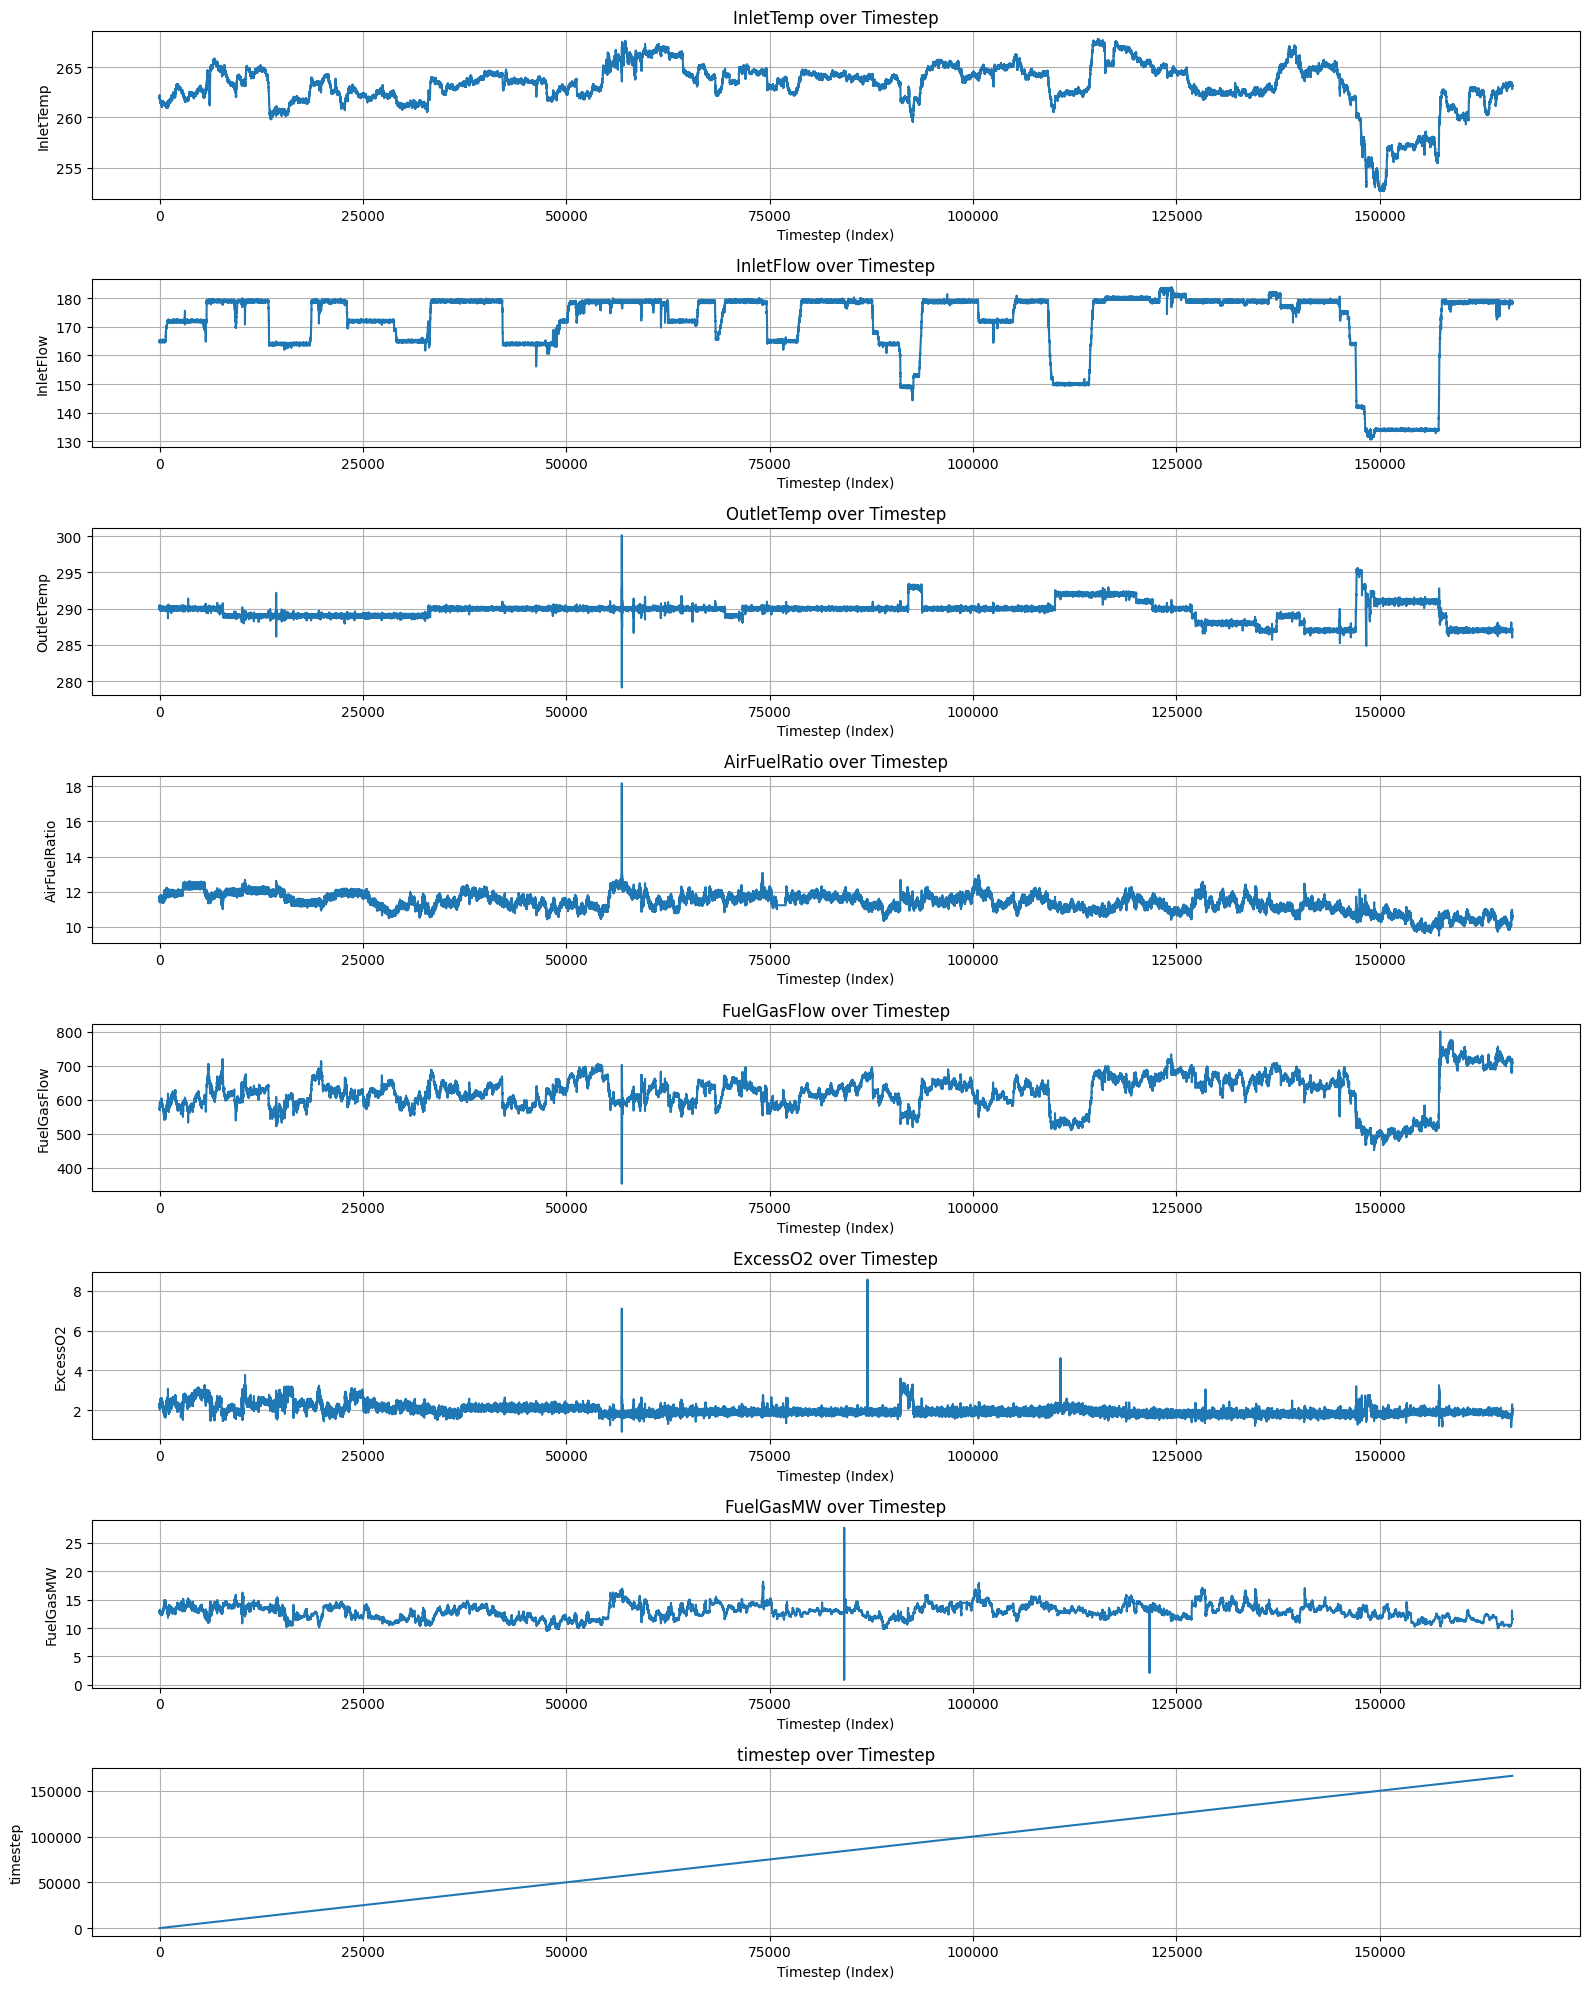

In [35]:
#let's plot and look at the data to determine how to fill up the missing values
%matplotlib inline

import matplotlib.pyplot as plt

features = df2.columns  # or specify your list: ['feat1', 'feat2', ...]
n = len(features)

plt.figure(figsize=(16, 2.5 * n))  # Height scales with number of features

for i, col in enumerate(features, 1):
    plt.subplot(n, 1, i)
    plt.plot(df2.index, df2[col])
    plt.title(f"{col} over Timestep")
    plt.xlabel("Timestep (Index)")
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
#alriggt, seems like forward fill is the best, let's do that and compare our results
df_fill = df2.ffill()

In [37]:
df_fill.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166288 entries, 0 to 166287
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InletTemp     166288 non-null  float64
 1   InletFlow     166288 non-null  float64
 2   OutletTemp    166288 non-null  float64
 3   AirFuelRatio  166288 non-null  float64
 4   FuelGasFlow   166288 non-null  float64
 5   ExcessO2      166288 non-null  float64
 6   FuelGasMW     166288 non-null  float64
 7   timestep      166288 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 11.4 MB


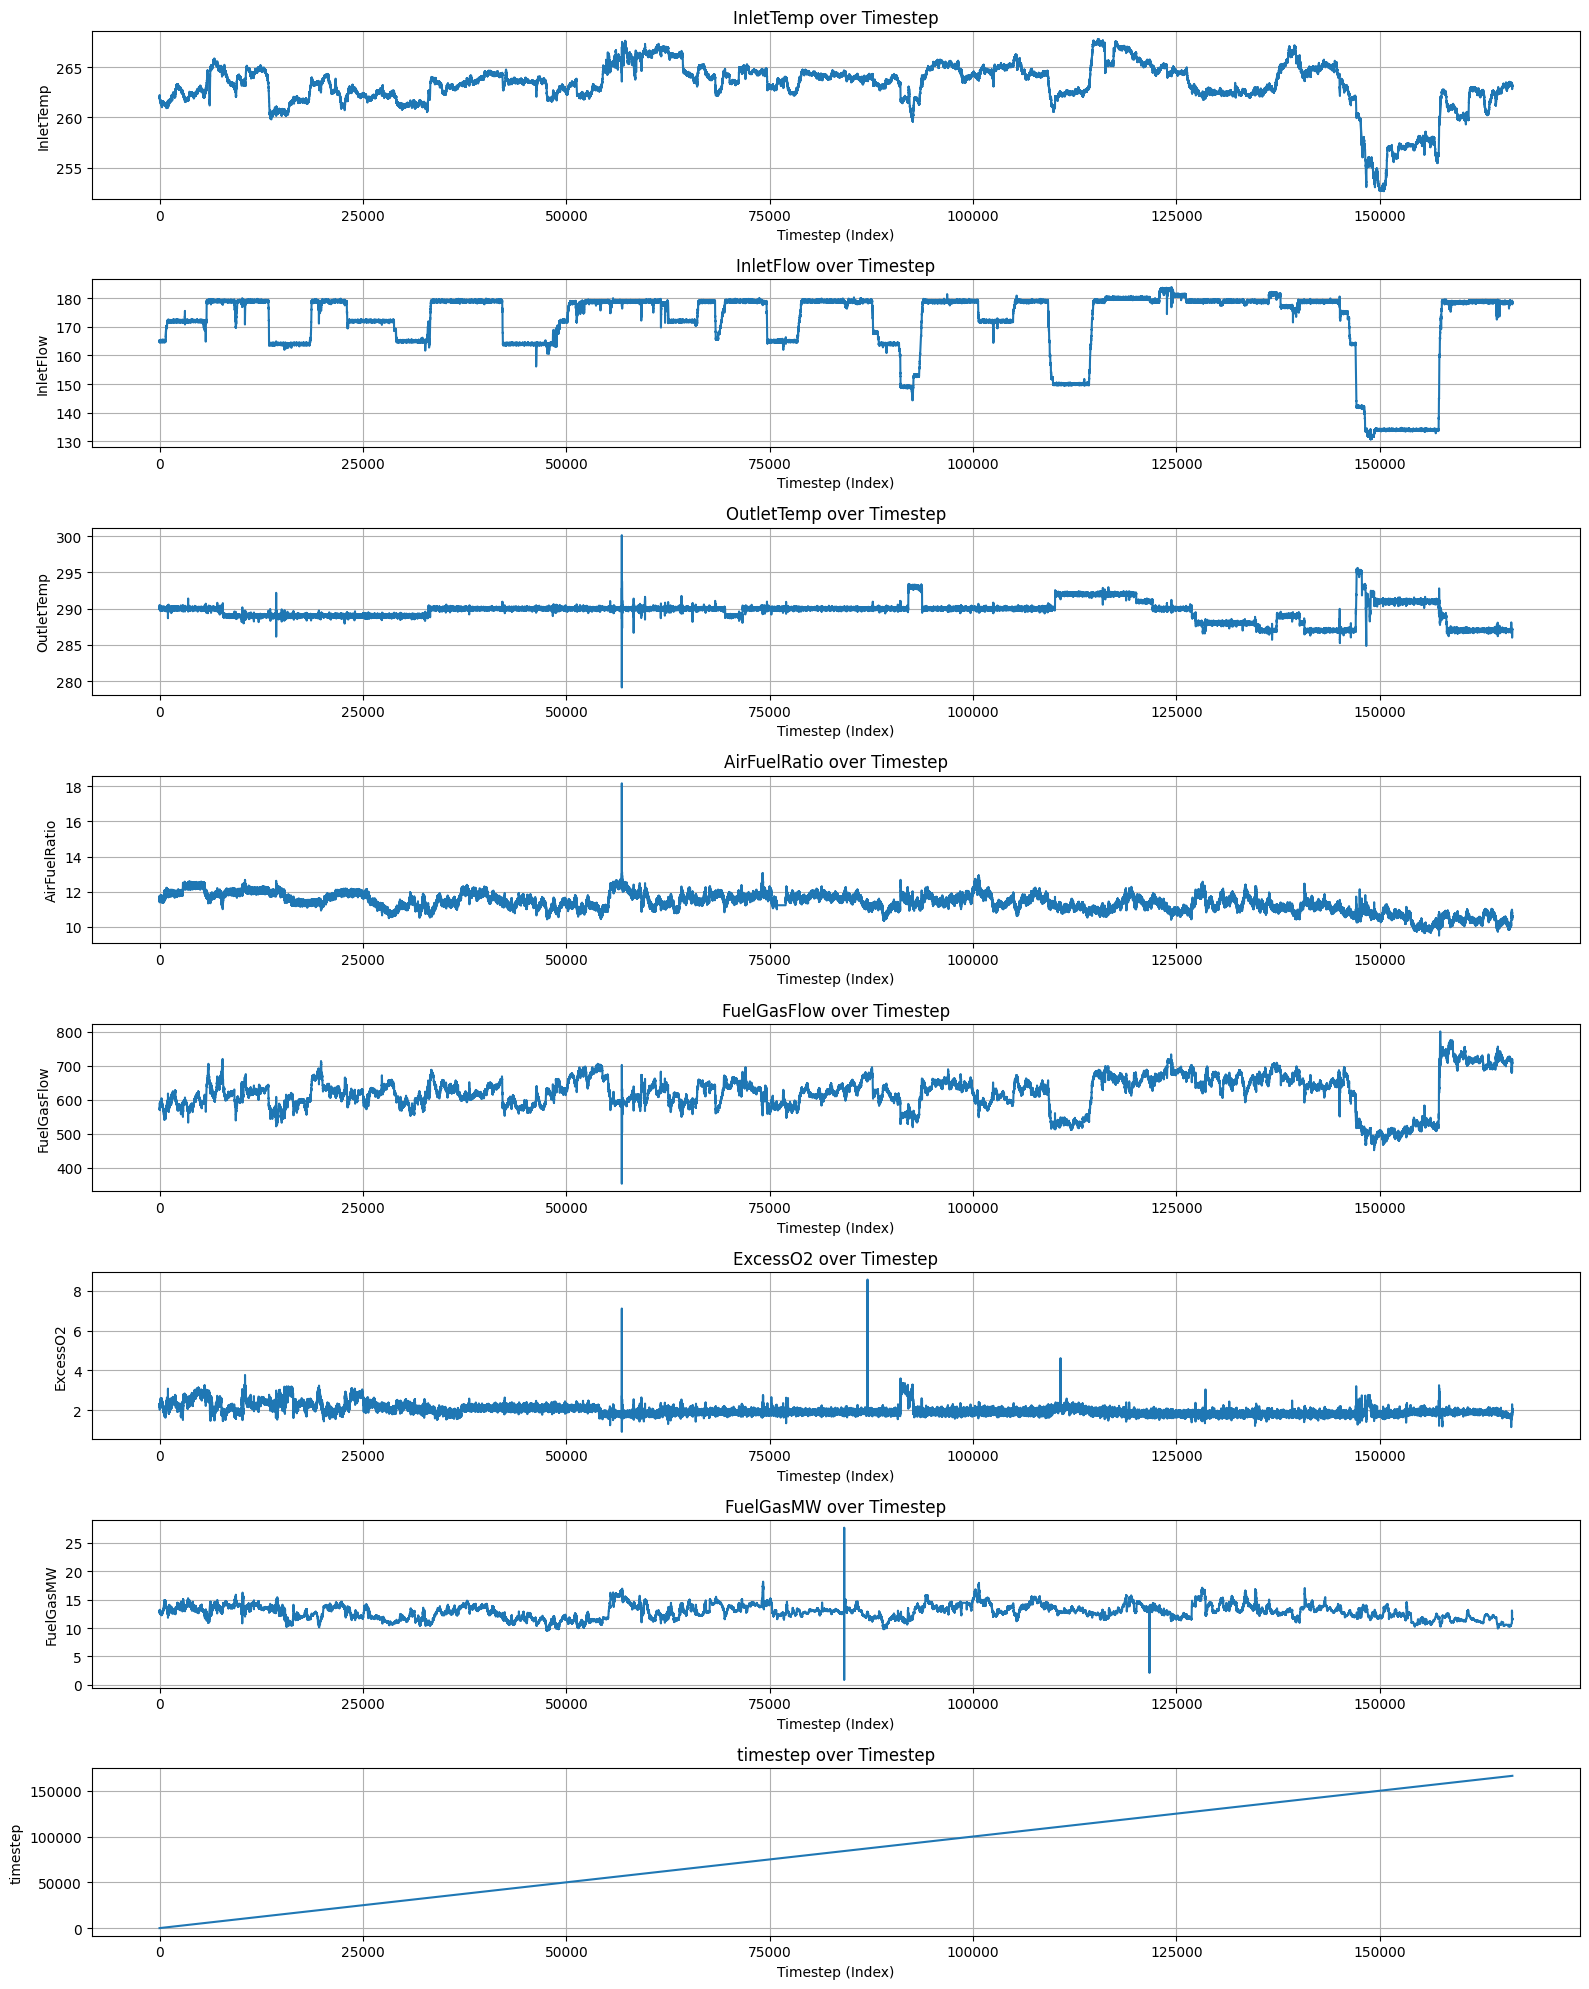

In [38]:
#lets plot again
%matplotlib inline

features = df_fill.columns  # or specify your list: ['feat1', 'feat2', ...]
n = len(features)

plt.figure(figsize=(16, 2.5 * n))  # Height scales with number of features

for i, col in enumerate(features, 1):
    plt.subplot(n, 1, i)
    plt.plot(df_fill.index, df_fill[col])
    plt.title(f"{col} over Timestep")
    plt.xlabel("Timestep (Index)")
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

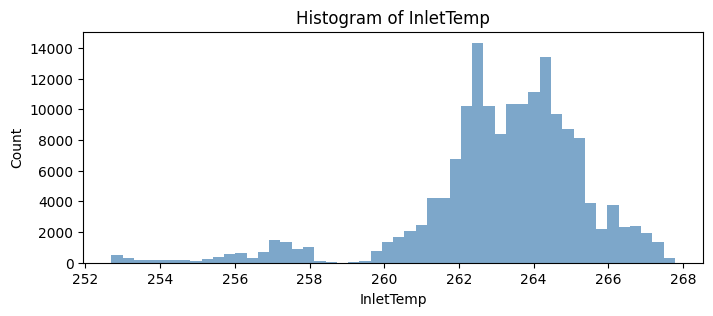

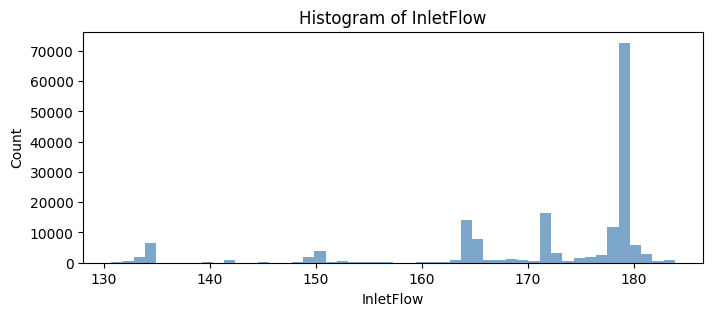

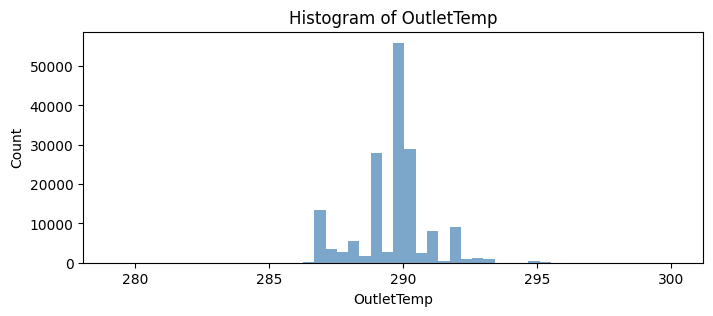

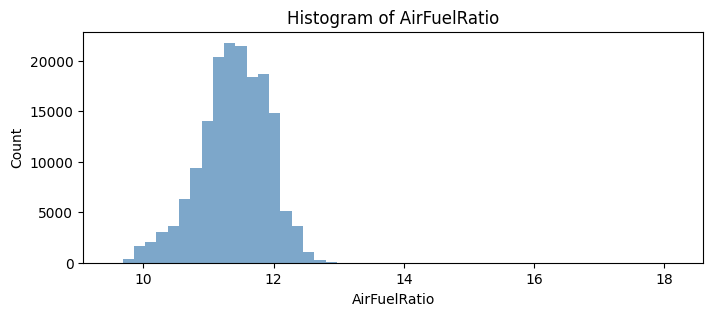

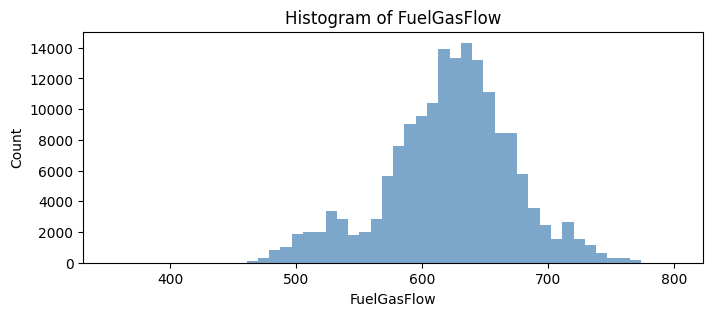

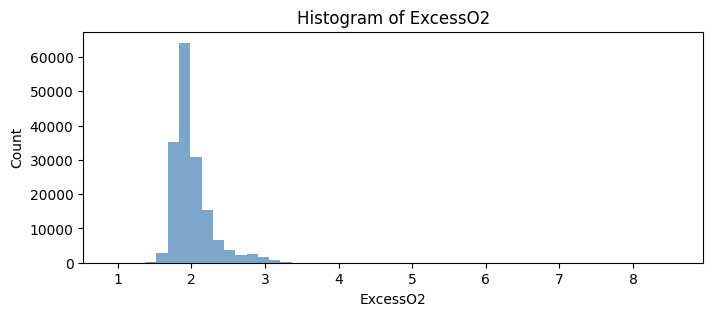

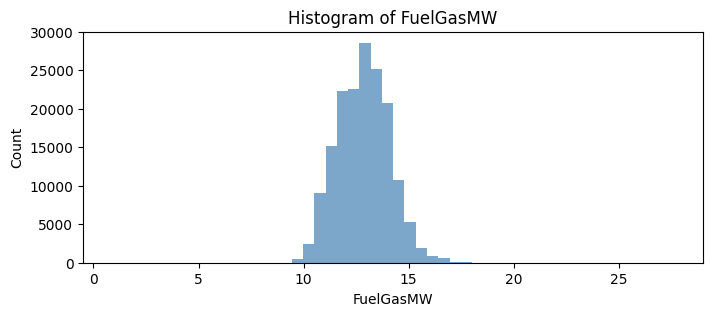

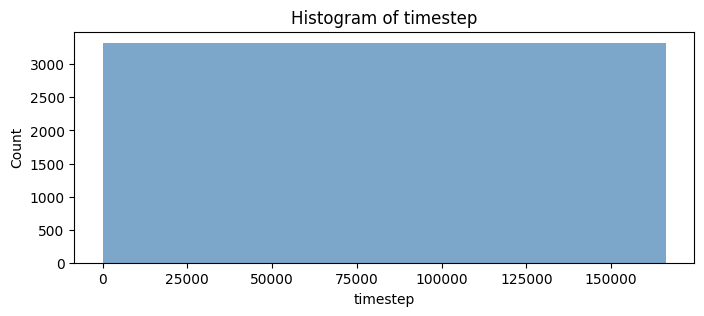

In [40]:
#alright, seems like it is ok. let's find the outlier and remove them
%matplotlib inline

for col in df_fill.columns:
    plt.figure(figsize = (8,3))
    plt.hist(df_fill[col].dropna(), bins =50, alpha = 0.7, color = 'steelblue')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [41]:
#let's remove the outlier and ffill that outlier
feature_cols = [col for col in df_fill.columns if col != 'timestep']

df3 = df_fill.copy()

z_score_limit = 3

for col in feature_cols:
    if np.issubdtype(df3[col].dtype,np.number):
        mean = df3[col].mean()
        std  = df3[col].std()
        outliers = (df3[col] < mean - z_score_limit *std) | (df3[col] > mean + z_score_limit *std)
        df3.loc[outliers,col] = np.nan


df3[feature_cols] = df3[feature_cols].ffill()

In [1]:
df3[feature_cols] = df3[feature_cols].ffill()

NameError: name 'df3' is not defined

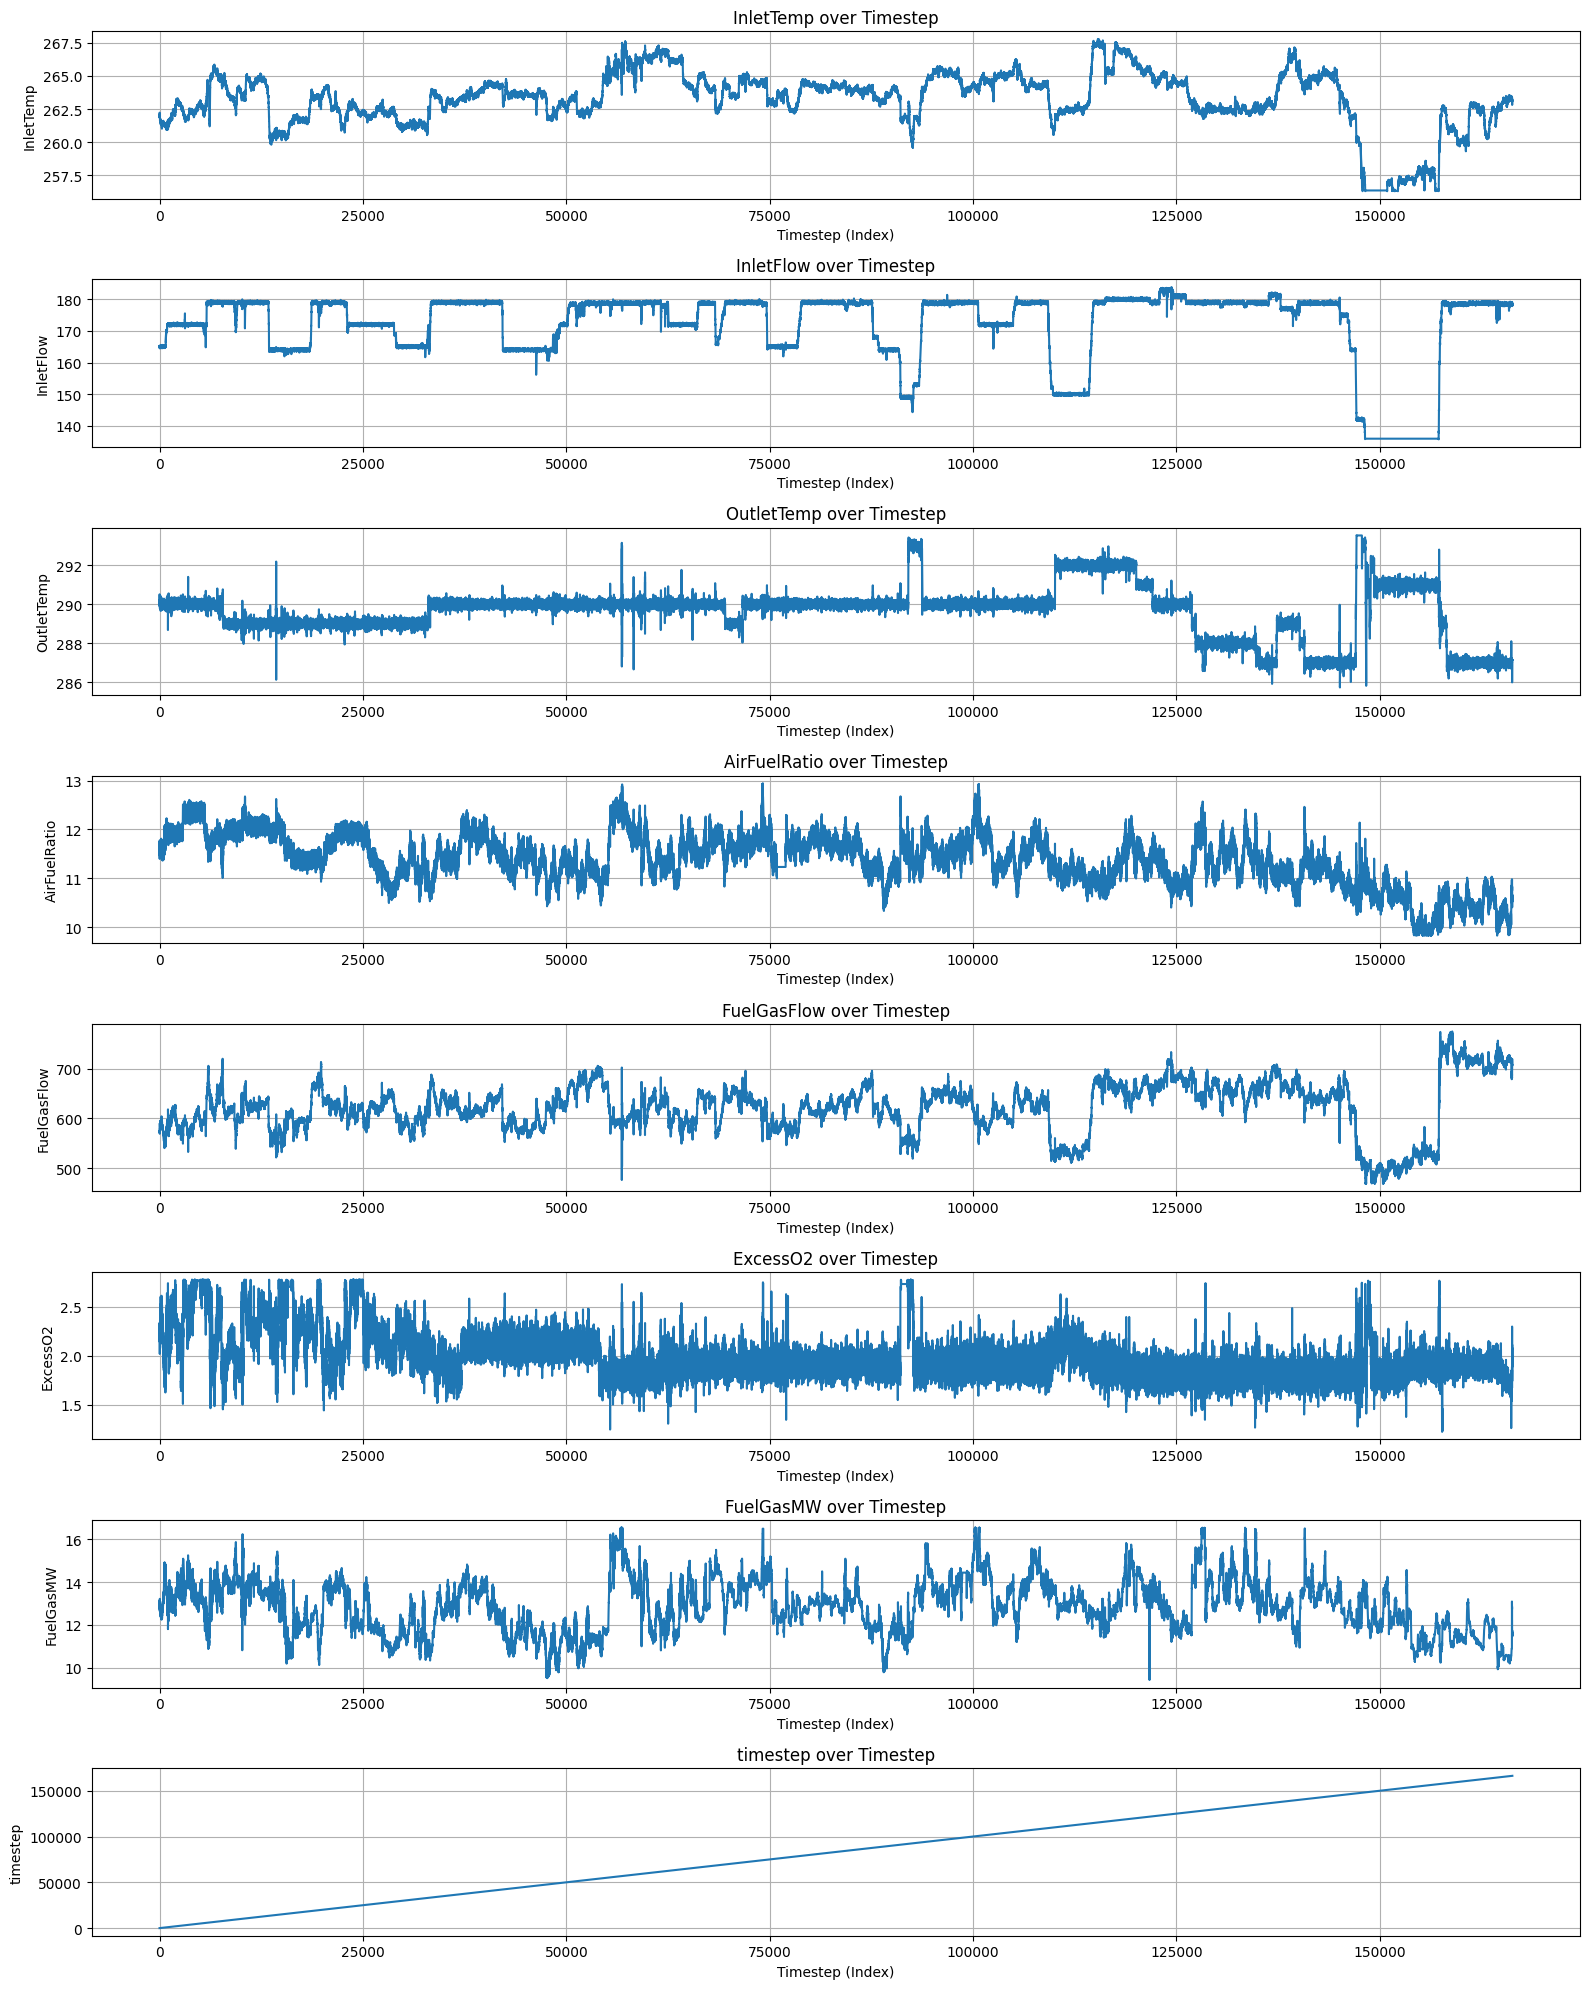

In [43]:
%matplotlib inline

features = df3.columns
n = len(features)

plt.figure(figsize=(16, 2.5 * n))  # Height scales with number of features

for i, col in enumerate(features, 1):
    plt.subplot(n, 1, i)
    plt.plot(df3.index, df3[col])
    plt.title(f"{col} over Timestep")
    plt.xlabel("Timestep (Index)")
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
#alrighrt now it's time to do some noise removal. this will help in preprocessing the data next
window_size = 5

feature_cols = [col for col in df3.columns if col != 'timestep']

df_smooth = df3.copy()
df_smooth[feature_cols] = df3[feature_cols].rolling(window = window_size, center =True, min_periods = 1).mean()

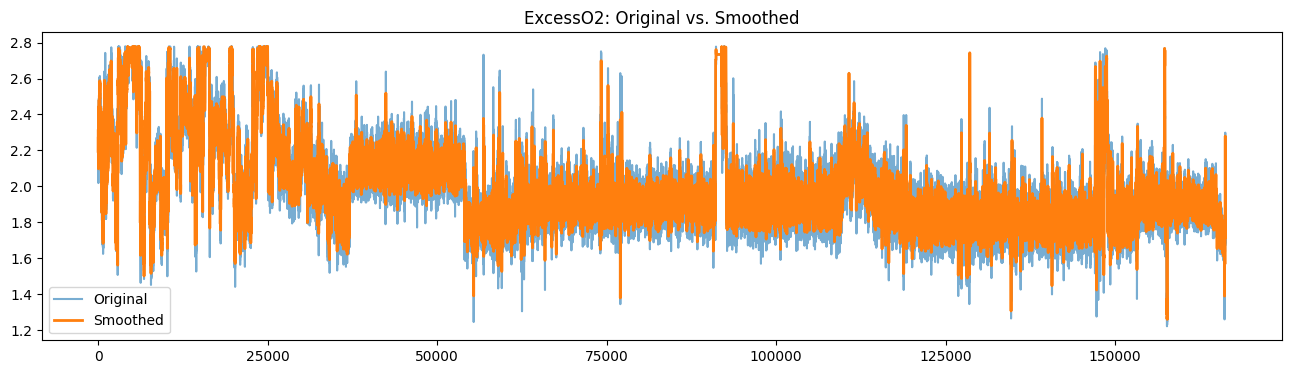

In [51]:
import matplotlib.pyplot as plt

col = feature_cols[5]  # Replace with any feature name

plt.figure(figsize=(16,4))
plt.plot(df3['timestep'], df3[col], label='Original', alpha=0.6)
plt.plot(df_smooth['timestep'], df_smooth[col], label='Smoothed', linewidth=2)
plt.legend()
plt.title(f"{col}: Original vs. Smoothed")
plt.show()

In [53]:
#let's save the data and maybe check the data dynamics to verify we have enough dyanmics
df_smooth.to_csv('smoothed_data.csv',index = False)